In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval (x) if pd.notna(x) else x)


In [2]:
df_da_ind = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()
df_da_ind = df_da_ind.dropna(subset = ['salary_year_avg'])
df_da_ind= df_da_ind.explode('job_skills')
df_da_ind_grp = df_da_ind.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by= 'median', ascending=False)
df_da_top_pay = df_da_ind_grp.sort_values(by='median', ascending=False).head(10)
df_da_skills = df_da_ind_grp.sort_values(by='count', ascending=False).head(10)


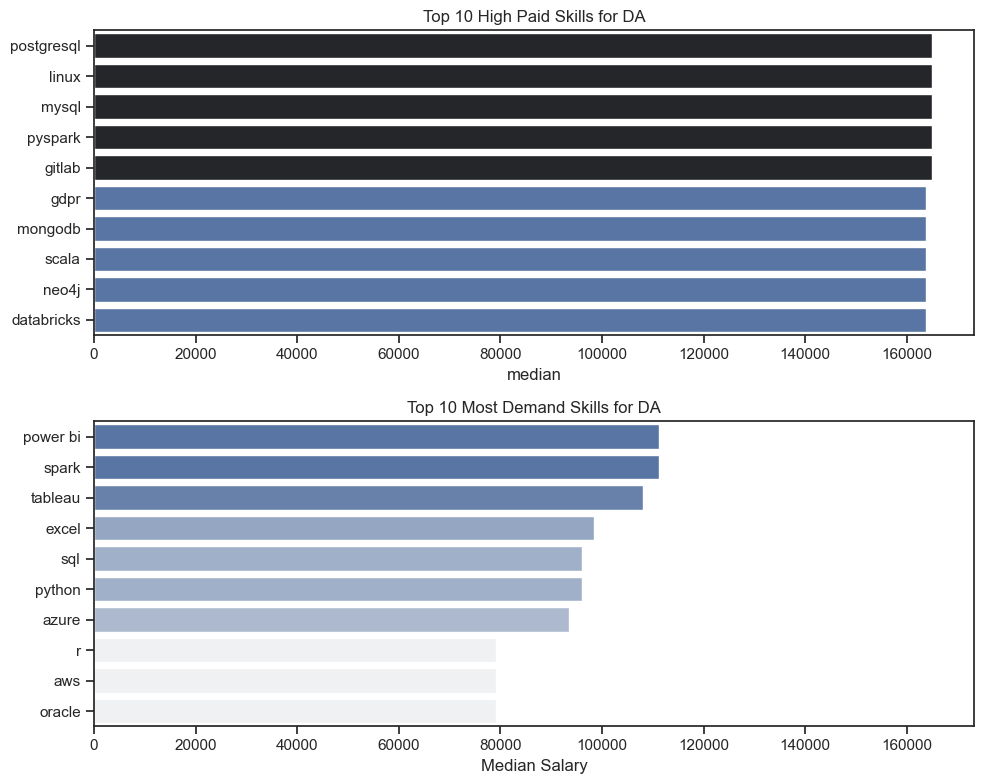

In [11]:
df_da_top_pay = df_da_ind_grp.sort_values(by='median', ascending=False).head(10)
df_da_skills = df_da_ind_grp.sort_values(by='count', ascending= False).head(10).sort_values(by='median', ascending=False)

fig, ax = plt.subplots(2, 1, figsize=(10,8))

sns.set_theme(style='ticks')

sns.barplot(data=df_da_top_pay, x='median' , y=df_da_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
ax[0].legend().remove()

ax[0].set_title('Top 10 High Paid Skills for DA')
ax[0].set_ylabel('')

sns.barplot(data=df_da_skills, x='median', y=df_da_skills.index, ax=ax[1], hue='median', palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Top 10 Most Demand Skills for DA')
ax[1].set_xlabel('Median Salary')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()
plt.show()

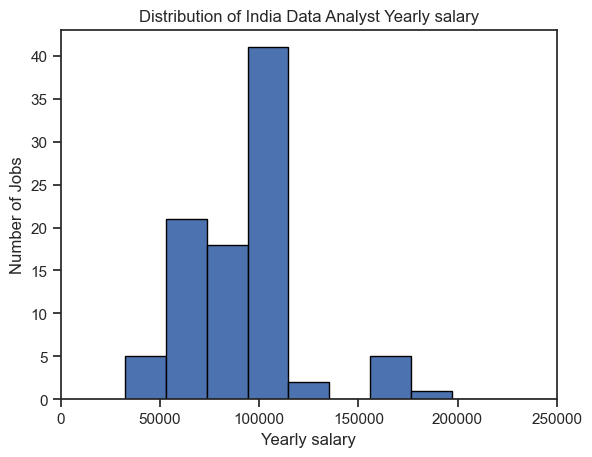

In [23]:
df_india_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()
df_india_da['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')
plt.xlim(0,250000)
ax= plt.gca()


plt.title('Distribution of India Data Analyst Yearly salary')
plt.xlabel('Yearly salary')
plt.ylabel ('Number of Jobs')
plt.show()

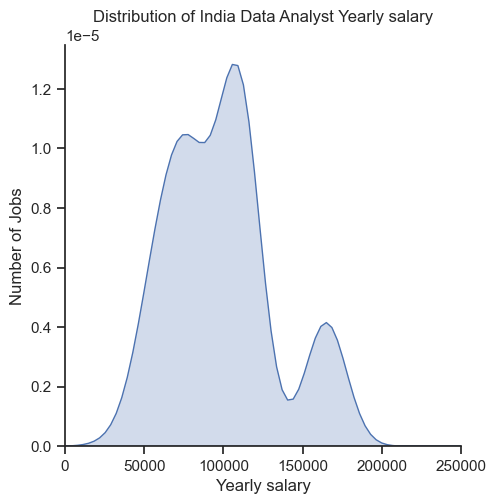

In [22]:
sns.displot(df_da_ind['salary_year_avg'], kind='kde', fill= True)
plt.title('Distribution of India Data Analyst Yearly salary')
plt.xlabel('Yearly salary')
plt.ylabel ('Number of Jobs')
plt.xlim(0, 250000)
plt.show()

C:\Users\Bhavya\AppData\Local\Temp\ipykernel_22268\1465046754.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


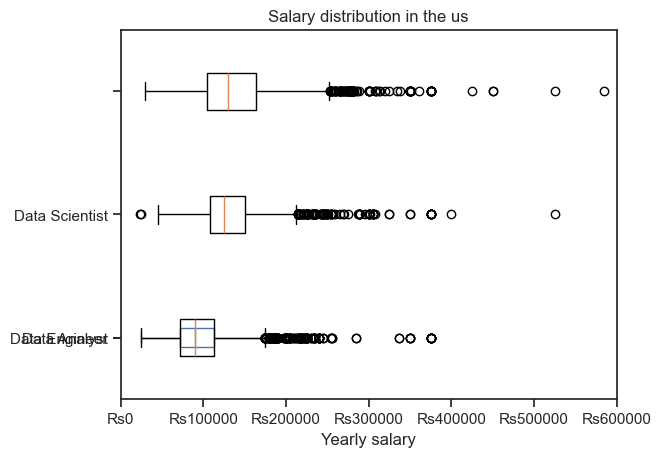

In [25]:
df_us_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_us_da = df_us_da.dropna(subset=['salary_year_avg'])
df_us_da['salary_year_avg'].sample(10)
df_us_da['salary_year_avg'].plot(kind='box', vert=False)
job_titles= ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_us = df_us.dropna(subset=['salary_year_avg'])
job_list = [df_us[df_us['job_title_short']== job_title] ['salary_year_avg']for job_title in job_titles]
plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary distribution in the us')
plt.xlabel('Yearly salary')
plt.xlim(0, 600000)
ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'Rs{int(y/1)}'))
plt.show()

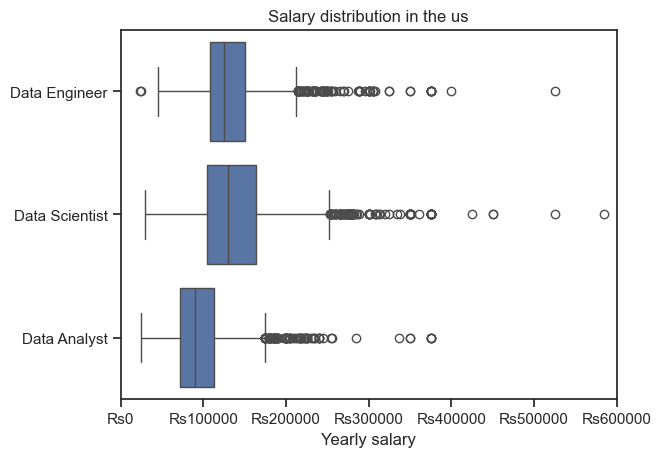

In [27]:
sns.boxplot(data=df_us, x='salary_year_avg', y='job_title_short')

plt.title('Salary distribution in the us')
plt.xlabel('Yearly salary')
plt.xlim(0, 600000)
plt.ylabel('')
ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'Rs{int(y/1)}'))
plt.show()